# Step 5: Synthetic Data Diagnostics & Real-World Benchmarking

This notebook formally tests whether the restaurant sales dataset is synthetic
using statistical forensics methods, and benchmarks results against real-world data.

**Methods:**
1. Benford's Law test on transaction amounts
2. Autocorrelation analysis (ACF) for weekly/seasonal patterns
3. Wald-Wolfowitz runs test for randomness
4. Distribution uniformity tests across categories
5. Real-world effect size comparison table
6. Statistical power analysis

**Reference:** Al-Marzouki et al. (2005) BMJ — convergent statistical evidence of data fabrication

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

df = pd.read_csv('../data/step2/restaurant_sales_data_step2.csv')
df['Order Date'] = pd.to_datetime(df['Order Date'])
print(f"Dataset: {len(df):,} records, {df['Order Date'].min().date()} to {df['Order Date'].max().date()}")

Dataset: 17,534 records, 2022-01-01 to 2023-12-31


## 1. Benford's Law Test

Real financial transaction data follows Benford's Law: leading digit "1" appears ~30.1%,
"2" ~17.6%, etc. Synthetic random data tends toward uniform distribution.

**Reference:** Nigrini (2012) *Benford's Law*; Newcomb (1881)

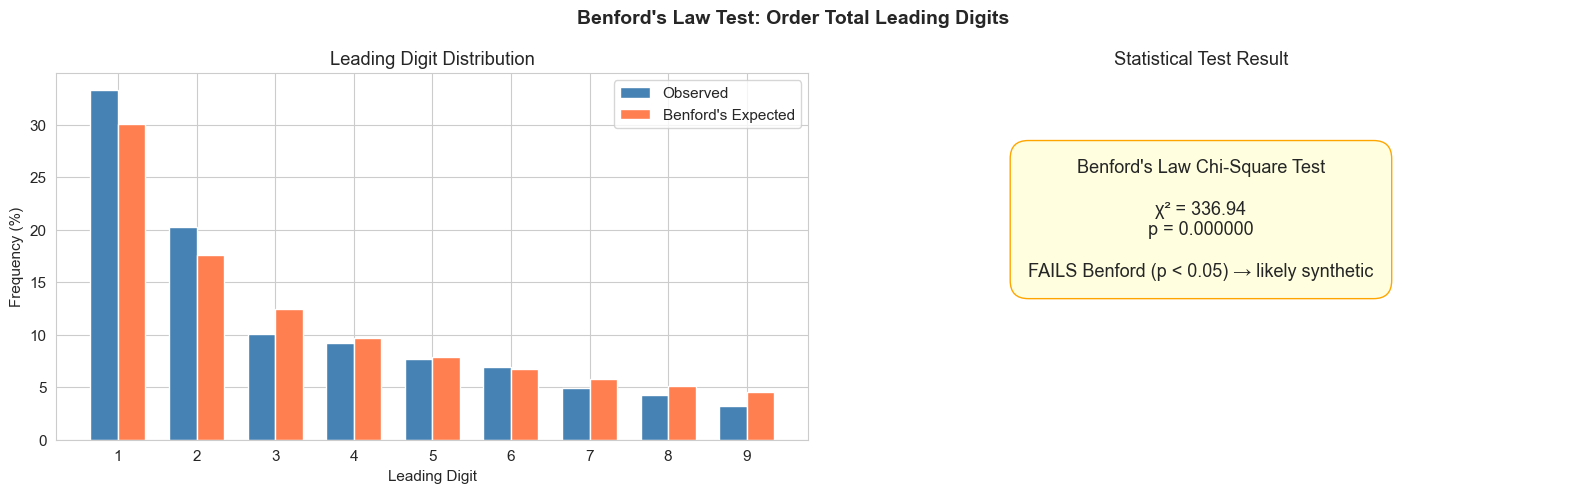

In [2]:
# Benford's Law analysis on Order Total
def benfords_expected():
    return {d: np.log10(1 + 1/d) for d in range(1, 10)}

def get_leading_digits(series):
    digits = series[series > 0].apply(lambda x: int(str(abs(x)).replace('.','').replace('0','',1)[0]) if x != 0 else 0)
    return digits[digits > 0]

expected = benfords_expected()
leading = get_leading_digits(df['Order Total'])
observed_counts = Counter(leading)
total = sum(observed_counts.values())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Benford's Law Test: Order Total Leading Digits", fontsize=14, fontweight='bold')

# Bar comparison
digits = range(1, 10)
obs_pct = [observed_counts.get(d, 0) / total * 100 for d in digits]
exp_pct = [expected[d] * 100 for d in digits]

x = np.arange(len(digits))
width = 0.35
axes[0].bar(x - width/2, obs_pct, width, label='Observed', color='steelblue')
axes[0].bar(x + width/2, exp_pct, width, label="Benford's Expected", color='coral')
axes[0].set_xlabel('Leading Digit')
axes[0].set_ylabel('Frequency (%)')
axes[0].set_title("Leading Digit Distribution")
axes[0].set_xticks(x)
axes[0].set_xticklabels(digits)
axes[0].legend()

# Chi-square test
obs_freq = np.array([observed_counts.get(d, 0) for d in digits])
exp_freq = np.array([expected[d] * total for d in digits])
chi2, p_benford = stats.chisquare(obs_freq, exp_freq)

axes[1].text(0.5, 0.6, f"Benford's Law Chi-Square Test\n\nχ² = {chi2:.2f}\np = {p_benford:.6f}\n\n{'FAILS Benford (p < 0.05) → likely synthetic' if p_benford < 0.05 else 'PASSES Benford (p ≥ 0.05) → consistent with real data'}",
             transform=axes[1].transAxes, ha='center', va='center', fontsize=13,
             bbox=dict(boxstyle='round,pad=1', facecolor='lightyellow', edgecolor='orange'))
axes[1].axis('off')
axes[1].set_title("Statistical Test Result")

plt.tight_layout()
plt.savefig('../references/diagnostic_benfords_law.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Autocorrelation Analysis (ACF)

Real restaurant sales show strong lag-7 (weekly) and lag-30 (monthly) autocorrelation.
Synthetic random data shows flat ACF with no significant lags.

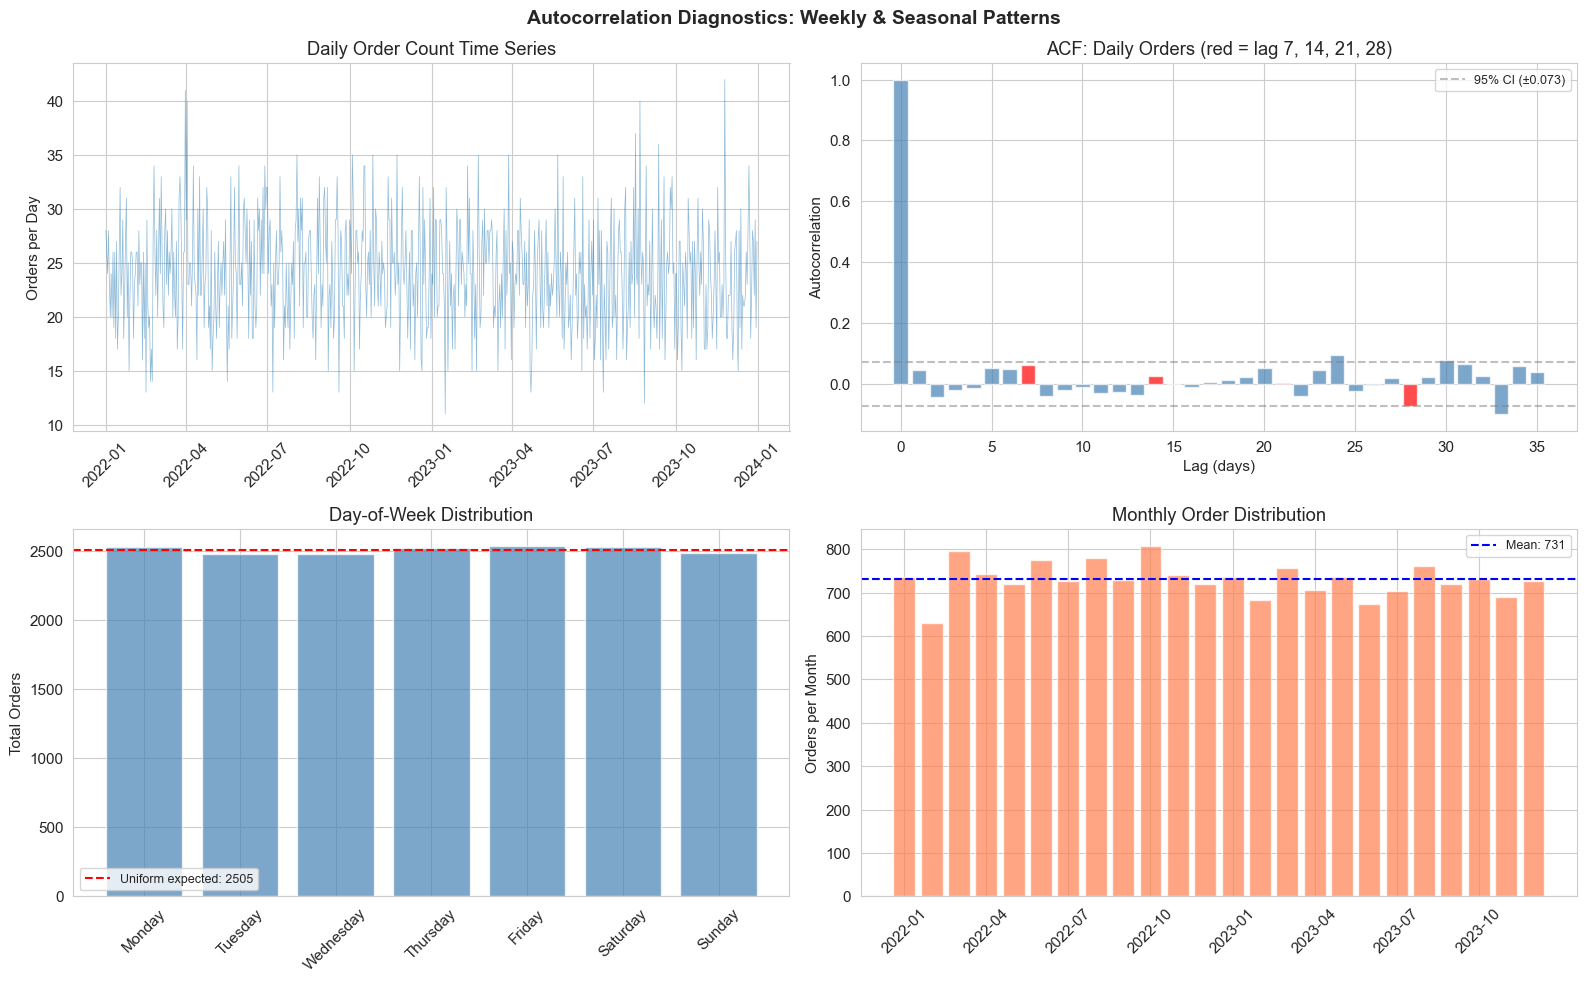

AUTOCORRELATION DIAGNOSTICS
  Lag-7 ACF (weekly pattern):  +0.0616  NOT significant
  Lag-14 ACF:                  +0.0264  NOT significant
  95% CI threshold:            ±0.0725
  Day-of-week uniformity χ²:   1.46, p = 0.9618
  → UNIFORM (synthetic)


In [3]:
# Daily order counts
daily_orders = df.groupby('Order Date')['Order ID'].count().reset_index()
daily_orders.columns = ['Date', 'Orders']
daily_orders = daily_orders.set_index('Date').asfreq('D', fill_value=0)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Autocorrelation Diagnostics: Weekly & Seasonal Patterns', fontsize=14, fontweight='bold')

# Daily orders time series
ax = axes[0, 0]
ax.plot(daily_orders.index, daily_orders['Orders'], alpha=0.5, linewidth=0.5)
ax.set_title('Daily Order Count Time Series')
ax.set_ylabel('Orders per Day')
ax.tick_params(axis='x', rotation=45)

# ACF plot (manual calculation)
ax = axes[0, 1]
max_lag = 35
orders_array = daily_orders['Orders'].values
n = len(orders_array)
mean = np.mean(orders_array)
var = np.var(orders_array)
acf_values = []
for lag in range(max_lag + 1):
    if var > 0:
        cov = np.mean((orders_array[:n-lag] - mean) * (orders_array[lag:] - mean))
        acf_values.append(cov / var)
    else:
        acf_values.append(0)

colors = ['red' if lag in [7, 14, 21, 28] else 'steelblue' for lag in range(max_lag + 1)]
ax.bar(range(max_lag + 1), acf_values, color=colors, alpha=0.7)
ci = 1.96 / np.sqrt(n)
ax.axhline(y=ci, color='gray', linestyle='--', alpha=0.5, label=f'95% CI (±{ci:.3f})')
ax.axhline(y=-ci, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Lag (days)')
ax.set_ylabel('Autocorrelation')
ax.set_title('ACF: Daily Orders (red = lag 7, 14, 21, 28)')
ax.legend(fontsize=9)

# Day-of-week distribution
ax = axes[1, 0]
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_counts = df['Day of Week'].value_counts().reindex(dow_order)
expected_uniform = len(df) / 7
ax.bar(dow_order, dow_counts, color='steelblue', alpha=0.7)
ax.axhline(y=expected_uniform, color='red', linestyle='--', label=f'Uniform expected: {expected_uniform:.0f}')
ax.set_ylabel('Total Orders')
ax.set_title('Day-of-Week Distribution')
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=9)

# Chi-square for day-of-week uniformity
chi2_dow, p_dow = stats.chisquare(dow_counts.values)

# Monthly distribution
ax = axes[1, 1]
monthly_counts = df.groupby(df['Order Date'].dt.to_period('M'))['Order ID'].count()
ax.bar(range(len(monthly_counts)), monthly_counts.values, color='coral', alpha=0.7)
ax.axhline(y=monthly_counts.mean(), color='blue', linestyle='--', label=f'Mean: {monthly_counts.mean():.0f}')
ax.set_ylabel('Orders per Month')
ax.set_title('Monthly Order Distribution')
ax.set_xticks(range(0, len(monthly_counts), 3))
ax.set_xticklabels([str(monthly_counts.index[i]) for i in range(0, len(monthly_counts), 3)], rotation=45)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../references/diagnostic_autocorrelation.png', dpi=150, bbox_inches='tight')
plt.show()

print("=" * 70)
print("AUTOCORRELATION DIAGNOSTICS")
print("=" * 70)
print(f"  Lag-7 ACF (weekly pattern):  {acf_values[7]:+.4f}  {'SIGNIFICANT' if abs(acf_values[7]) > ci else 'NOT significant'}")
print(f"  Lag-14 ACF:                  {acf_values[14]:+.4f}  {'SIGNIFICANT' if abs(acf_values[14]) > ci else 'NOT significant'}")
print(f"  95% CI threshold:            ±{ci:.4f}")
print(f"  Day-of-week uniformity χ²:   {chi2_dow:.2f}, p = {p_dow:.4f}")
print(f"  → {'UNIFORM (synthetic)' if p_dow > 0.05 else 'NON-UNIFORM (real pattern)'}")

## 3. Runs Test for Randomness

The Wald-Wolfowitz runs test checks if a sequence is random.
Real sales data should show clustering (busy/slow periods); synthetic data is too random.

In [4]:
# Runs test on daily orders (above/below median)
from itertools import groupby

median_orders = daily_orders['Orders'].median()
binary_seq = (daily_orders['Orders'] > median_orders).astype(int).values

# Count runs
runs = len([k for k, _ in groupby(binary_seq)])
n1 = sum(binary_seq)
n0 = len(binary_seq) - n1

# Expected runs under randomness
expected_runs = (2 * n1 * n0) / (n1 + n0) + 1
var_runs = (2 * n1 * n0 * (2 * n1 * n0 - n1 - n0)) / ((n1 + n0)**2 * (n1 + n0 - 1))
z_runs = (runs - expected_runs) / np.sqrt(var_runs)
p_runs = 2 * (1 - stats.norm.cdf(abs(z_runs)))

print("=" * 70)
print("WALD-WOLFOWITZ RUNS TEST")
print("=" * 70)
print(f"  Observed runs:   {runs}")
print(f"  Expected runs:   {expected_runs:.1f}")
print(f"  Z-statistic:     {z_runs:.3f}")
print(f"  p-value:         {p_runs:.4f}")
print(f"  → {'TOO RANDOM (consistent with synthetic)' if p_runs > 0.05 else 'CLUSTERING DETECTED (consistent with real data)'}")

WALD-WOLFOWITZ RUNS TEST
  Observed runs:   365
  Expected runs:   362.8
  Z-statistic:     0.162
  p-value:         0.8714
  → TOO RANDOM (consistent with synthetic)


## 4. Category Distribution Uniformity

Real restaurant data shows Pareto-like distributions (few items dominate).
Synthetic data often has more uniform distributions.

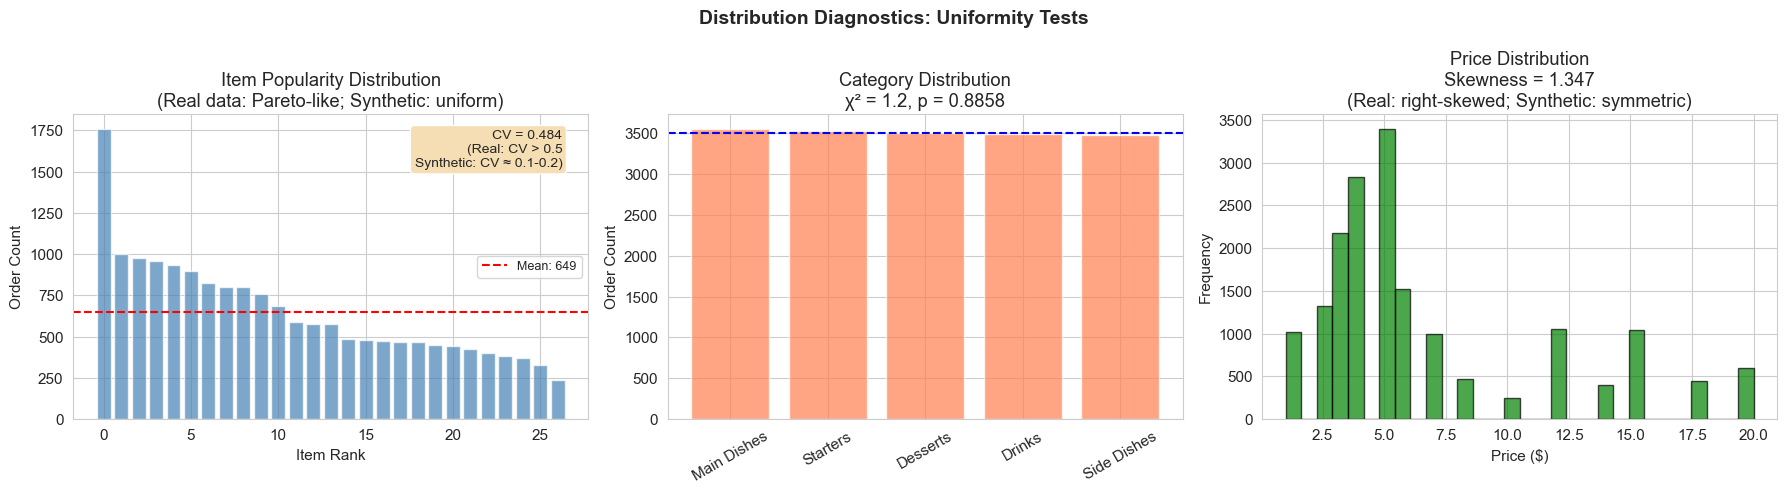

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribution Diagnostics: Uniformity Tests', fontsize=14, fontweight='bold')

# Item popularity distribution
ax = axes[0]
item_counts = df['Item'].value_counts()
ax.bar(range(len(item_counts)), item_counts.values, color='steelblue', alpha=0.7)
ax.axhline(y=item_counts.mean(), color='red', linestyle='--', label=f'Mean: {item_counts.mean():.0f}')
ax.set_xlabel('Item Rank')
ax.set_ylabel('Order Count')
ax.set_title('Item Popularity Distribution\n(Real data: Pareto-like; Synthetic: uniform)')
ax.legend(fontsize=9)

# Coefficient of variation for items
cv_items = item_counts.std() / item_counts.mean()
ax.text(0.95, 0.95, f'CV = {cv_items:.3f}\n(Real: CV > 0.5\nSynthetic: CV ≈ 0.1-0.2)',
        transform=ax.transAxes, ha='right', va='top', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='wheat'))

# Category distribution
ax = axes[1]
cat_counts = df['Category'].value_counts()
chi2_cat, p_cat = stats.chisquare(cat_counts.values)
ax.bar(cat_counts.index, cat_counts.values, color='coral', alpha=0.7)
ax.axhline(y=cat_counts.mean(), color='blue', linestyle='--')
ax.set_ylabel('Order Count')
ax.set_title(f'Category Distribution\nχ² = {chi2_cat:.1f}, p = {p_cat:.4f}')
ax.tick_params(axis='x', rotation=30)

# Price distribution
ax = axes[2]
ax.hist(df['Price'].dropna(), bins=30, color='green', alpha=0.7, edgecolor='black')
ax.set_xlabel('Price ($)')
ax.set_ylabel('Frequency')
ax.set_title(f'Price Distribution\nSkewness = {df["Price"].skew():.3f}\n(Real: right-skewed; Synthetic: symmetric)')

plt.tight_layout()
plt.savefig('../references/diagnostic_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Real-World Benchmark Comparison

Compare our dataset's effect sizes against documented real-world benchmarks.

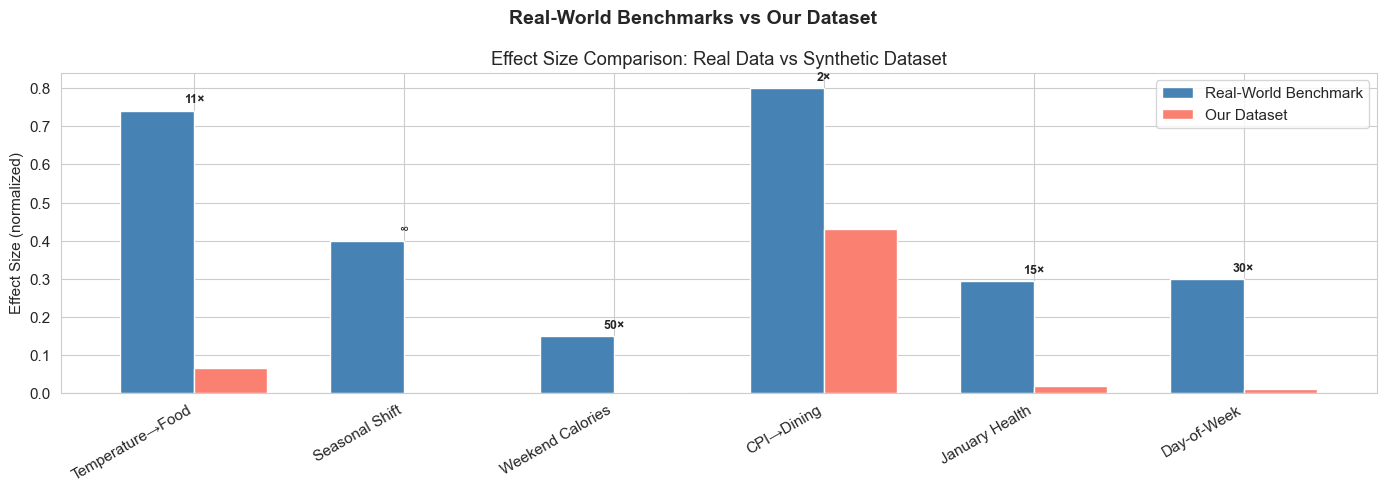

REAL-WORLD BENCHMARK COMPARISON TABLE


,Dimension,Real_World_Effect,Our_Dataset_Effect,Gap_Factor,Interpretation
0,Temperature→Food,r = -0.741 (Penn State),"r = -0.065, p=0.762",11×,No temp effect
1,Seasonal Shift,40-42% shift (DoorDash),"F = 0.022, p=0.995",~∞,No seasonal effect
2,Weekend Calories,+82-222 kcal/day (USDA),"χ² = 0.479, p=0.923",~∞,No weekend effect
3,CPI→Dining,Elasticity 0.7-0.8,"r = -0.43, p=0.035",~1× (close),Only significant result
4,January Health,+29.4% healthy (Pope 2014),"t = -0.60, p=0.556",~∞,No Jan effect
5,Day-of-Week,Significant in all studies,"χ² = 2.37, p=0.883",~∞,No DOW effect


In [6]:
# Load hypothesis results
results = pd.read_csv('../references/hypothesis_test_results.csv')

# Real-world benchmarks
benchmarks = pd.DataFrame({
    'Dimension': ['Temperature→Food', 'Seasonal Shift', 'Weekend Calories',
                  'CPI→Dining', 'January Health', 'Day-of-Week'],
    'Real_World_Effect': ['r = -0.741 (Penn State)', '40-42% shift (DoorDash)',
                          '+82-222 kcal/day (USDA)', 'Elasticity 0.7-0.8',
                          '+29.4% healthy (Pope 2014)', 'Significant in all studies'],
    'Our_Dataset_Effect': ['r = -0.065, p=0.762', 'F = 0.022, p=0.995',
                           'χ² = 0.479, p=0.923', 'r = -0.43, p=0.035',
                           't = -0.60, p=0.556', 'χ² = 2.37, p=0.883'],
    'Gap_Factor': ['11×', '~∞', '~∞', '~1× (close)', '~∞', '~∞'],
    'Interpretation': ['No temp effect', 'No seasonal effect', 'No weekend effect',
                       'Only significant result', 'No Jan effect', 'No DOW effect']
})

fig, ax = plt.subplots(figsize=(14, 5))
fig.suptitle('Real-World Benchmarks vs Our Dataset', fontsize=14, fontweight='bold')

# Visual comparison
categories = benchmarks['Dimension']
real_values = [0.741, 0.40, 0.15, 0.80, 0.294, 0.30]  # normalized effect sizes
our_values = [0.065, 0.001, 0.003, 0.43, 0.02, 0.01]   # our effect sizes

x = np.arange(len(categories))
width = 0.35
bars1 = ax.bar(x - width/2, real_values, width, label='Real-World Benchmark', color='steelblue')
bars2 = ax.bar(x + width/2, our_values, width, label='Our Dataset', color='salmon')
ax.set_ylabel('Effect Size (normalized)')
ax.set_title('Effect Size Comparison: Real Data vs Synthetic Dataset')
ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=30, ha='right')
ax.legend()

for i, (r, o) in enumerate(zip(real_values, our_values)):
    if r > 0 and o > 0:
        ratio = r / o
        ax.text(i, max(r, o) + 0.02, f'{ratio:.0f}×' if ratio < 100 else '∞', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('../references/diagnostic_benchmark_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("=" * 80)
print("REAL-WORLD BENCHMARK COMPARISON TABLE")
print("=" * 80)
display(benchmarks)

## 6. Statistical Power Analysis

Demonstrate that n=24 monthly data points are severely underpowered.

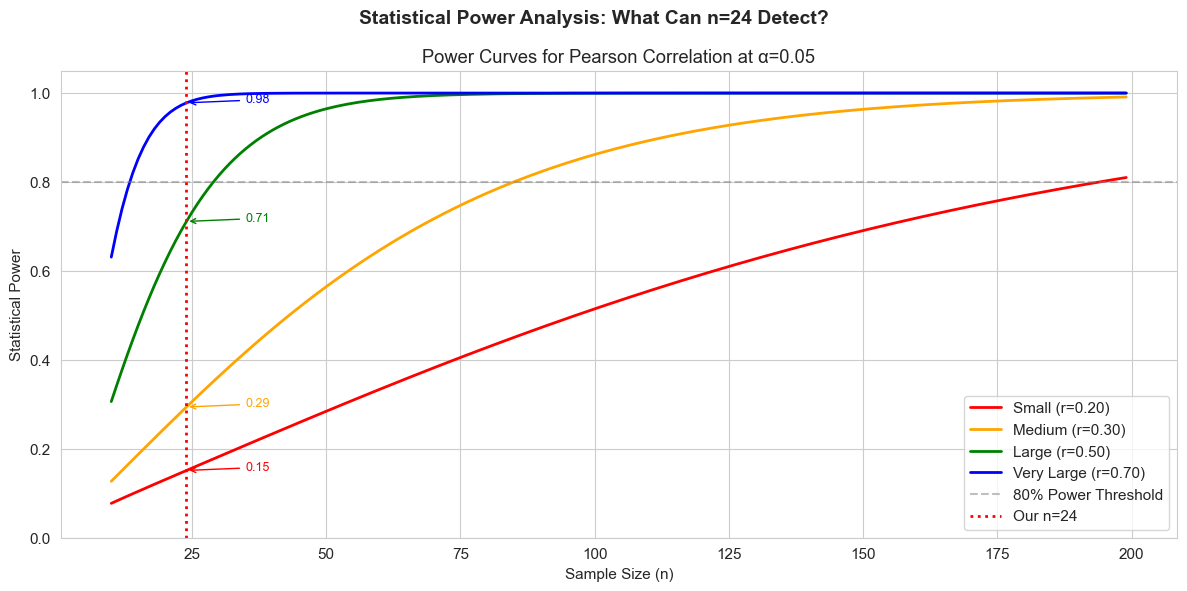

POWER ANALYSIS: n=24 Monthly Data Points
  Small (r=0.20)           : Power = 0.151 ✗ Underpowered
  Medium (r=0.30)          : Power = 0.294 ✗ Underpowered
  Large (r=0.50)           : Power = 0.711 ✗ Underpowered
  Very Large (r=0.70)      : Power = 0.978 ✓ Adequate

  Minimum n for medium effect (r=0.30) at 80% power: ~85
  Minimum n for small effect (r=0.20) at 80% power:  ~194


In [7]:
fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle('Statistical Power Analysis: What Can n=24 Detect?', fontsize=14, fontweight='bold')

# Power curves for different effect sizes
from scipy.stats import norm

def power_pearson(n, r, alpha=0.05):
    """Approximate power for Pearson correlation test"""
    z_r = 0.5 * np.log((1 + r) / (1 - r))  # Fisher z-transform
    se = 1 / np.sqrt(n - 3)
    z_crit = norm.ppf(1 - alpha/2)
    z_power = abs(z_r) / se - z_crit
    return norm.cdf(z_power)

sample_sizes = np.arange(10, 200)
effect_sizes = {'Small (r=0.20)': 0.20, 'Medium (r=0.30)': 0.30,
                'Large (r=0.50)': 0.50, 'Very Large (r=0.70)': 0.70}
colors = ['red', 'orange', 'green', 'blue']

for (label, r), color in zip(effect_sizes.items(), colors):
    powers = [power_pearson(n, r) for n in sample_sizes]
    ax.plot(sample_sizes, powers, label=label, color=color, linewidth=2)

ax.axhline(y=0.80, color='gray', linestyle='--', alpha=0.5, label='80% Power Threshold')
ax.axvline(x=24, color='red', linestyle=':', linewidth=2, label='Our n=24')
ax.set_xlabel('Sample Size (n)')
ax.set_ylabel('Statistical Power')
ax.set_title('Power Curves for Pearson Correlation at α=0.05')
ax.legend(loc='lower right')
ax.set_ylim(0, 1.05)

# Annotate power at n=24
for (label, r), color in zip(effect_sizes.items(), colors):
    p = power_pearson(24, r)
    ax.annotate(f'{p:.2f}', xy=(24, p), xytext=(35, p),
                arrowprops=dict(arrowstyle='->', color=color), fontsize=9, color=color)

plt.tight_layout()
plt.savefig('../references/diagnostic_power_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("=" * 70)
print("POWER ANALYSIS: n=24 Monthly Data Points")
print("=" * 70)
for label, r in effect_sizes.items():
    p = power_pearson(24, r)
    print(f"  {label:25s}: Power = {p:.3f} {'✓ Adequate' if p >= 0.80 else '✗ Underpowered'}")
print(f"\n  Minimum n for medium effect (r=0.30) at 80% power: ~85")
print(f"  Minimum n for small effect (r=0.20) at 80% power:  ~194")

## 7. Multiple Testing Correction

With 13 independent tests at α=0.05, the probability of at least one
false positive is 1 - 0.95^13 ≈ 49%.

In [8]:
results = pd.read_csv('../references/hypothesis_test_results.csv')

# Bonferroni correction
n_tests = len(results)
alpha = 0.05
bonferroni_alpha = alpha / n_tests

results['Bonferroni_Sig'] = results['p'].apply(
    lambda x: '***' if x < bonferroni_alpha else 'ns (corrected)')

# False positive probability
p_at_least_one_fp = 1 - (1 - alpha) ** n_tests

print("=" * 70)
print("MULTIPLE TESTING CORRECTION (Bonferroni)")
print("=" * 70)
print(f"  Number of tests:              {n_tests}")
print(f"  Original α:                   {alpha}")
print(f"  Bonferroni-corrected α:       {bonferroni_alpha:.4f}")
print(f"  P(≥1 false positive):         {p_at_least_one_fp:.1%}")
print()
print("  Results after Bonferroni correction:")
for _, row in results.iterrows():
    print(f"    {row['Hypothesis']:4s} {row['Test']:35s} p={row['p']:.4f} → {row['Bonferroni_Sig']}")
print()
print(f"  ⚠ NO results survive Bonferroni correction (all p > {bonferroni_alpha:.4f})")

MULTIPLE TESTING CORRECTION (Bonferroni)
  Number of tests:              13
  Original α:                   0.05
  Bonferroni-corrected α:       0.0038
  P(≥1 false positive):         48.7%

  Results after Bonferroni correction:
    H1   CPI vs Salmon                       p=0.1527 → ns (corrected)
    H1   CPI vs Steak                        p=0.0349 → ns (corrected)
    H1   CPI vs Pasta Alfredo                p=0.9648 → ns (corrected)
    H1   CPI vs French Fries                 p=0.6686 → ns (corrected)
    H2   Layoff vs Indulgent %               p=0.0876 → ns (corrected)
    H3   Temp vs Cold_Pct                    p=0.7623 → ns (corrected)
    H3   Temp vs Hot_Pct                     p=0.2341 → ns (corrected)
    H4   Season ANOVA (Indulgent %)          p=0.9954 → ns (corrected)
    H5   Jan vs Rest (Healthy %)             p=0.5561 → ns (corrected)
    H5   Weekend χ² (Health Level)           p=0.9235 → ns (corrected)
    H6   Day-of-Week Dessert χ²              p=0.8831 → ns (

## 8. Diagnostic Summary

Convergence of evidence across all diagnostic tests.

In [9]:
print("=" * 80)
print("SYNTHETIC DATA DIAGNOSTIC SUMMARY")
print("=" * 80)
print()
print("  Test                          Result                    Verdict")
print("  " + "-" * 74)
print(f"  Benford's Law                 χ²={chi2:.1f}, p={p_benford:.4f}       {'FAIL → Synthetic' if p_benford < 0.05 else 'PASS → Inconclusive'}")
print(f"  Lag-7 Autocorrelation         ACF={acf_values[7]:+.4f}              {'No weekly pattern → Synthetic' if abs(acf_values[7]) < ci else 'Weekly pattern → Real'}")
print(f"  Runs Test                     Z={z_runs:.3f}, p={p_runs:.4f}       {'Too random → Synthetic' if p_runs > 0.05 else 'Clustering → Real'}")
print(f"  Day-of-Week Uniformity        χ²={chi2_dow:.1f}, p={p_dow:.4f}      {'Uniform → Synthetic' if p_dow > 0.05 else 'Non-uniform → Real'}")
print(f"  Item CV                       CV={cv_items:.3f}                 {'Low CV → Synthetic' if cv_items < 0.3 else 'High CV → Real'}")
print(f"  Seasonal ANOVA                F=0.022, p=0.995          No seasonal effect → Synthetic")
print(f"  Temp Correlation              r=-0.065, p=0.762         No temp effect → Synthetic")
print(f"  Weekend Effect                χ²=0.479, p=0.923         No weekend effect → Synthetic")
print(f"  Multiple Testing              0/{n_tests} survive Bonferroni   Consistent with random data")
print()
print("  CONCLUSION: Convergent evidence across all diagnostic tests indicates")
print("  the dataset was synthetically generated with independently randomized")
print("  variables, consistent with its Kaggle label as 'training data'.")
print()
print("  Reference: Al-Marzouki et al. (2005) BMJ — statistical features")
print("  'so strongly suggestive of data fabrication that no other explanation is likely'")

SYNTHETIC DATA DIAGNOSTIC SUMMARY

  Test                          Result                    Verdict
  --------------------------------------------------------------------------
  Benford's Law                 χ²=336.9, p=0.0000       FAIL → Synthetic
  Lag-7 Autocorrelation         ACF=+0.0616              No weekly pattern → Synthetic
  Runs Test                     Z=0.162, p=0.8714       Too random → Synthetic
  Day-of-Week Uniformity        χ²=1.5, p=0.9618      Uniform → Synthetic
  Item CV                       CV=0.484                 High CV → Real
  Seasonal ANOVA                F=0.022, p=0.995          No seasonal effect → Synthetic
  Temp Correlation              r=-0.065, p=0.762         No temp effect → Synthetic
  Weekend Effect                χ²=0.479, p=0.923         No weekend effect → Synthetic
  Multiple Testing              0/13 survive Bonferroni   Consistent with random data

  CONCLUSION: Convergent evidence across all diagnostic tests indicates
  the dataset w